In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

/home/jcthompson5@ad.wisc.edu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")
df_exp4a = pd.read_csv("data/exp4/exp4_metabolites_best_reps.csv")
df_exp4b = pd.read_csv("data/exp4/exp4_metabolites_new_best.csv")
df_exp4c = pd.read_csv("data/exp4/exp4_metabolites_new_worst.csv")

df = pd.concat((df_exp0, df_exp1, df_exp2, df_exp3, df_exp4a, df_exp4b, df_exp4c))

In [3]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))
system_variables

array(['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs',
       'CHabs', 'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs',
       'RIabs', 'pH', 'Lactate', 'Butyrate', 'Acetate', 'AcGum', 'ArGal',
       'Inulin', 'Pectin', 'Starch', 'Xylan'], dtype='<U8')

In [4]:
# scale data 
scaler = MinMaxScaler(observed, system_variables)
scaler.fit(df)
df_scaled = scaler.transform(df.copy())

# format data into matrix [n_samples, n_timepoints, dt+n_outputs+n_controls]
data = format_data(df.copy(), species, metabolites, controls, observed=observed)
data_scaled = format_data(df_scaled, species, metabolites, controls, observed=observed)

# instantiate model
brnn = miRNN(n_species=len(species), n_metabolites=len(metabolites), n_controls=len(controls), n_hidden=32)
# fit model
brnn.fit(data_scaled, evd_tol=1e-3)

Total measurements: 27517, Number of parameters: 2515, Initial regularization: 0.00e+00
Loss: 1429.134, Residuals: -0.00633
Loss: 1345.974, Residuals: -0.00327
Loss: 1316.323, Residuals: -0.00082
Loss: 1285.769, Residuals: -0.00132
Loss: 1170.579, Residuals: 0.00147
Loss: 1144.611, Residuals: -0.00382
Loss: 1098.094, Residuals: -0.00274
Loss: 1011.266, Residuals: -0.00266
Loss: 929.189, Residuals: -0.00162
Loss: 886.026, Residuals: -0.00242
Loss: 840.357, Residuals: -0.00421
Loss: 828.633, Residuals: -0.00429
Loss: 818.472, Residuals: -0.00198
Loss: 801.120, Residuals: -0.00273
Loss: 777.498, Residuals: -0.00269
Loss: 775.382, Residuals: -0.00308
Loss: 754.145, Residuals: -0.00309
Loss: 714.870, Residuals: -0.00285
Loss: 714.203, Residuals: -0.00284
Loss: 686.828, Residuals: -0.00293
Loss: 658.182, Residuals: -0.00346
Loss: 656.110, Residuals: -0.00311
Loss: 636.528, Residuals: -0.00279
Loss: 603.775, Residuals: -0.00223
Loss: 602.632, Residuals: -0.00234
Loss: 591.798, Residuals: -0.0

In [5]:
# full factorial of both species and controls 
n_species = len(species)
n_fibers  = len(controls)

# create matrix of all possible communities
Slist = [np.reshape(np.array(i), (1, n_species)) for i in itertools.product([0, 1], repeat = n_species)]
# remove all zeros community
S = np.array(np.concatenate(Slist)[1:], float)

# create matrix of all possible fiber combinations
Flist = [np.reshape(np.array(i), (1, n_fibers)) for i in itertools.product([0, 1], repeat = n_fibers)]
# remove all zeros combination
F = np.array(np.concatenate(Flist)[1:], float)

# matrix of species and fiber indeces 
M = np.array(np.zeros([S.shape[0]*F.shape[0], 2]), int)
k = 0 
for i in range(S.shape[0]):
    for j in range(F.shape[0]):
        M[k, 0] = int(i)
        M[k, 1] = int(j)
        k += 1

# function to pull sample data 
def gen_exp_cond(k):
    s_ind, f_ind = M[k]
    return S[s_ind], F[f_ind]

# function to generate informative name of experimental condition
def gen_exp_name(Si, Fi):
    exp_name = ""
    for i,si in enumerate(Si):
        if si > 0:
            exp_name += species[i].split("abs")[0] + "-"
    for i,fi in enumerate(Fi):
        if fi > 0:
            exp_name += controls[i] + "-"
    return exp_name[:-1]

In [6]:
def format_design_data(S, F, t_eval, scaler, batch_size=512):

    # data is a list of tuples (T, X, U, Y, names) where each tuple corresponds to a batch
    data = []
    
    # total number of samples
    n_samples = S.shape[0] * F.shape[0]
    k = 0 
    
    # number of evaluation times
    n_eval = len(t_eval)

    # divide data into batches
    for batch_inds in tqdm(np.array_split(np.arange(n_samples), np.ceil(n_samples / batch_size))):

        # initialize data matrices 
        T = np.empty([len(batch_inds), n_eval])
        T[:] = t_eval
        X = np.empty([len(batch_inds), S.shape[-1]+len(metabolites)])
        X[:] = np.nan
        U = np.empty([len(batch_inds), n_eval, F.shape[-1]])
        U[:] = np.nan

        # keep track of experiment names
        names = []
        for i, batch_ind in enumerate(batch_inds):

            # pull sample data 
            Si, Fi = gen_exp_cond(k)

            # keep track of experiment names
            names.append(gen_exp_name(Si, Fi))

            # store initial condition data
            X[i, :len(Si)] = .000667 * Si
            
            # initial pH and metabolites
            X[i, len(Si):] = np.array([6.7, 0., 0., 0.])
            
            # scale observed variables 
            X[i] = (X[i] - scaler.scale_dict_obs["0 min"]) / scaler.scale_dict_obs["0 max"]
            
            # store controls (already scaled)
            U[i] =  Fi / sum(Fi)
            
            # update counter
            k += 1

        data.append((T, X, U, names))

    return data

In [7]:
# format and scale data based on training data
design_data = format_design_data(S, F, np.array([0, 1, 2, 3]), scaler, batch_size=1024)

100%|██████████████████████████████████████| 2016/2016 [00:18<00:00, 107.53it/s]


In [222]:
# save predictions to dataframe
pred_dfs = []
# for T, X, U, Y, exp_names in data_scaled: 
for T, X, U, exp_names in design_data:
    
    # keep initial condition
    preds = np.array(brnn.predict_point(X, U))
    
    # unscale predictions
    for eval_time in scaler.eval_times:
        t_inds = T == eval_time
        preds[t_inds] *= (scaler.scale_dict_obs[f"{eval_time} max"] - scaler.scale_dict_obs[f"{eval_time} min"])
        preds[t_inds] += scaler.scale_dict_obs[f"{eval_time} min"]
    
    # get shapes
    batch_size, n_time, n_out = preds.shape
    
    # reshape arrays
    T = np.reshape(T, batch_size*n_time)
    U = np.reshape(U, [batch_size*n_time, U.shape[-1]])
    Y = np.reshape(preds, [batch_size*n_time, n_out])
    exp_names_array = np.reshape(np.array([np.tile(item, n_time) for item in exp_names]), n_time * len(exp_names))
    
    # save to df
    pred_df = pd.DataFrame()
    pred_df['Experiments'] = exp_names_array
    pred_df['Time'] = T
    pred_df[species+metabolites] = Y
    pred_df[controls] = U
    pred_dfs.append(pred_df)
    
pred_df = pd.concat(pred_dfs)

In [167]:
# # experimental data
# X = []
# y = []
# for exp, df_exp in df.groupby('Experiments'):
    
#     if df_exp.shape[0]==4:
#         X.append(df_exp[species+controls].values[0])
#         y.append(df_exp['Butyrate'].values[-1])
# X = np.array(np.array(X)>0, int)
# y = np.array(y)

In [223]:
# simulated data
X = np.array(pred_df.iloc[pred_df.Time.values==0][species+controls].values > 0, float)
y = pred_df.iloc[pred_df.Time.values==3]['Butyrate'].values

# # simulated data of exp
# X = []
# y = []
# for exp, df_exp in pred_df.groupby('Experiments'):
    
#     if df_exp.shape[0]==4:
#         X.append(df_exp[species+controls].values[0])
#         y.append(df_exp['Butyrate'].values[-1])
# X = np.array(np.array(X)>0, int)
# y = np.array(y)

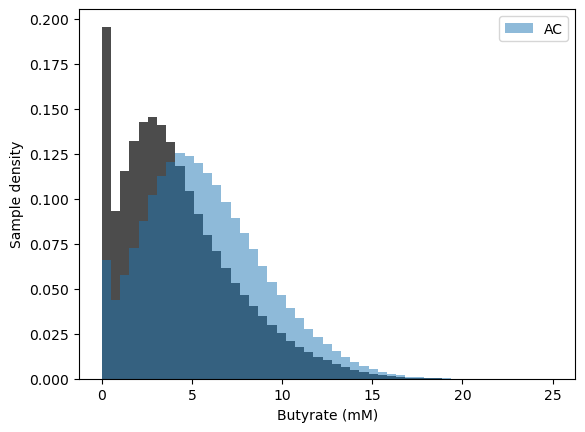

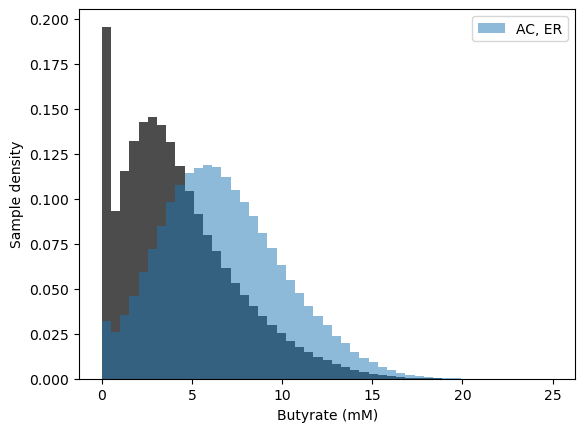

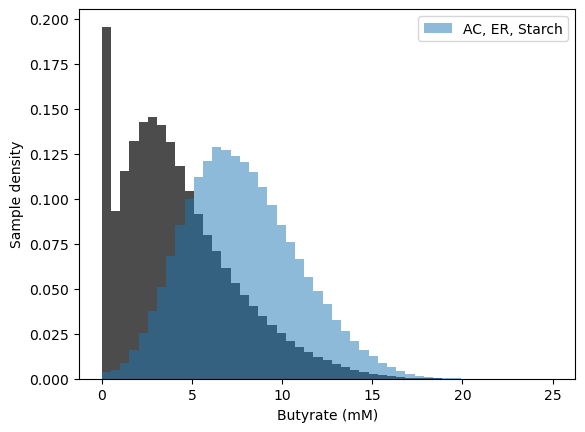

In [224]:
import itertools

# Value of k
for k in [1, 2, 3]:

    # Loop over all n choose k subsets
    motifs = []
    separation = []
    for motif in itertools.combinations(species+controls, k):

        # samples with motif 
        motif_inds = np.sum(X[:, np.in1d(species+controls, motif)], 1) == len(motif)

        if len(y[motif_inds])>0:
            motifs.append(motif)
            # separation.append(np.mean(y[motif_inds]) - np.mean(y[~motif_inds]))
            separation.append(np.median(y[motif_inds]) - np.median(y[~motif_inds]))        
            # separation.append(np.max(y[motif_inds]) - np.max(y[~motif_inds])) 
            # ks = ks_2samp(y[~motif_inds], y[motif_inds])
            # ks_dist = ks.statistic * ks.statistic_sign
            # separation.append(ks_dist)
            
    motif = motifs[np.argmax(separation)]
    motif_inds = np.sum(X[:, np.in1d(species+controls, motif)], 1) == len(motif)

    bins = np.linspace(0, 25)
    plt.hist(y, bins=bins, density=True, color='k', alpha=.7)
    
    label = ""
    for m in motif:
        label += m.split('abs')[0] + ', '
    label = label[:-2]
    plt.hist(y[motif_inds], bins=bins, alpha=.5, label=label, density=True)
    plt.legend()
    plt.xlabel("Butyrate (mM)")
    plt.ylabel("Sample density")
    plt.savefig(f"figures/sim_design_motif_{k}.svg", dpi=300)
    plt.show()

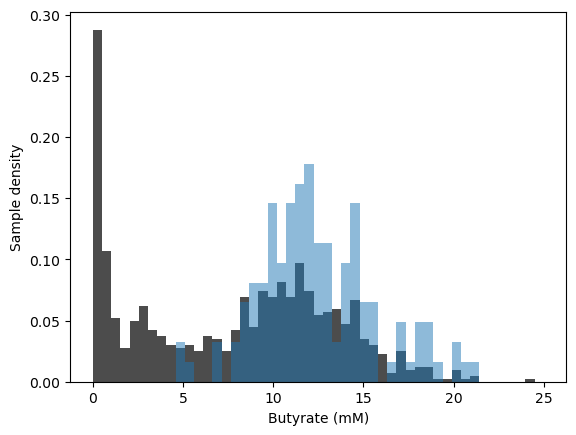

In [171]:
motif = ['ACabs', 'ERabs', 'Starch']
motif_inds = np.sum(X[:, np.in1d(species+controls, motif)], 1) == len(motif)

bins = np.linspace(0, 25)
plt.hist(y, bins=bins, density=True, color='k', alpha=.7)
plt.hist(y[motif_inds], bins=bins, alpha=.5, density=True)
plt.xlabel("Butyrate (mM)")
plt.ylabel("Sample density")
plt.show()

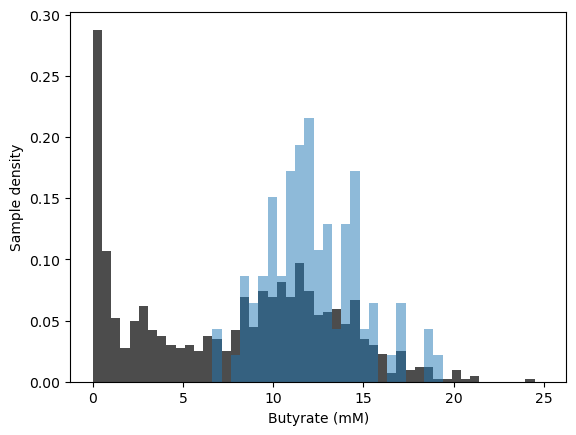

In [172]:
motif = ['ACabs', 'ERabs', 'BUabs', 'Inulin', 'Starch']
motif_inds = np.sum(X[:, np.in1d(species+controls, motif)], 1) == len(motif)

bins = np.linspace(0, 25)
plt.hist(y, bins=bins, density=True, color='k', alpha=.7)
plt.hist(y[motif_inds], bins=bins, alpha=.5, density=True)
plt.xlabel("Butyrate (mM)")
plt.ylabel("Sample density")
plt.show()

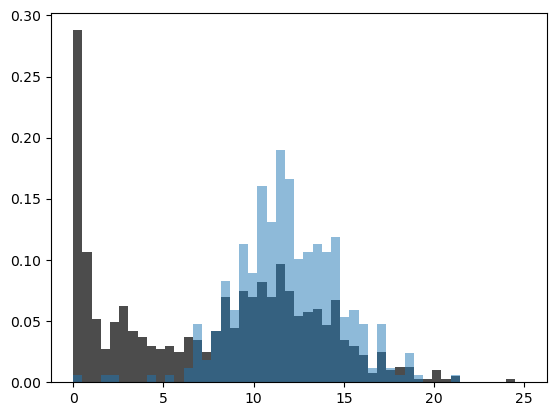

In [173]:
motif = ['ACabs', 'BUabs', 'Inulin']
motif_inds = np.sum(X[:, np.in1d(species+controls, motif)], 1) == len(motif)

bins = np.linspace(0, 25)
plt.hist(y, bins=bins, density=True, color='k', alpha=.7)
plt.hist(y[motif_inds], bins=bins, alpha=.5, density=True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=123, n_init="auto").fit(Xy)

In [ ]:
X0 = Xy[kmeans.labels_==0]
X1 = Xy[kmeans.labels_==1]

In [ ]:
plt.hist(X0[:, -1])
plt.hist(X1[:, -1], alpha=.5)
# plt.hist(X2[:, -1], alpha=.5)
plt.show()

In [192]:
# # Train a decision tree regressor
# max_depth = 4
# model = DecisionTreeRegressor(max_depth=max_depth)
# model.fit(X, y)

# # Plot the decision tree
# plt.figure(figsize=(50,30))
# tree.plot_tree(model, filled=True, feature_names=species+controls, rounded=True)
# plt.title(f"Decision Tree (max_depth={max_depth})")
# plt.savefig("figures/tree.pdf", dpi=300)
# plt.show()

In [177]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import _tree

# Train a decision tree regressor
max_depth = 10
model = DecisionTreeRegressor(max_depth=max_depth)
model.fit(X, y)

DecisionTreeRegressor(max_depth=10)

In [178]:
y_hat = model.predict(X)

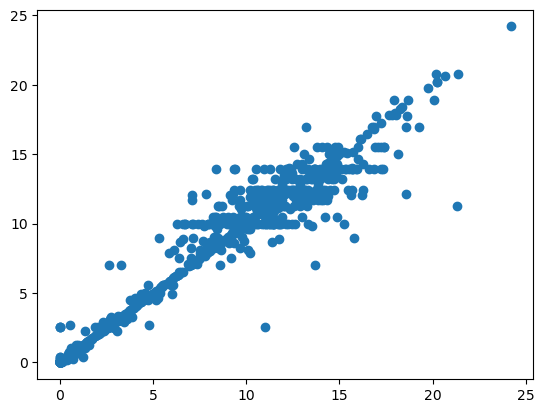

In [179]:
plt.scatter(y, y_hat)
plt.show()

In [180]:
np.max(y)

24.206144013

In [182]:
# Define a function to print decision rules leading to leaf nodes with large values
def print_large_leaf_rules(tree, feature_names, threshold=0.7):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    def recurse(node, depth, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold_value = tree_.threshold[node]
            path.append(f"{name} <= {threshold_value:.2f}")
            recurse(tree_.children_left[node], depth + 1, path)
            path.pop()

            path.append(f"{name} > {threshold_value:.2f}")
            recurse(tree_.children_right[node], depth + 1, path)
            path.pop()
        else:
            # If it's a leaf node
            value = tree_.value[node][0, 0]
            if value > threshold:  # Customize your condition for "large" values
                print(f"Decision path: {' -> '.join(path)}")
                print(f"Predicted value at leaf: {value:.2f}\n")

    recurse(0, 1, [])

# Print rules for leaf nodes with large values (you can adjust the threshold)
print_large_leaf_rules(model, feature_names=species+controls, threshold=20)


Decision path: ACabs <= 0.50 -> CCabs > 0.50 -> PCabs > 0.50 -> DFabs <= 0.50 -> Xylan > 0.50 -> BAabs <= 0.50 -> CHabs <= 0.50 -> FPabs > 0.50 -> PJabs <= 0.50
Predicted value at leaf: 20.22

Decision path: ACabs > 0.50 -> ArGal <= 0.50 -> AcGum <= 0.50 -> BUabs <= 0.50 -> Inulin <= 0.50 -> ERabs <= 0.50 -> RIabs > 0.50 -> BHabs > 0.50 -> CCabs <= 0.50 -> CAabs <= 0.50
Predicted value at leaf: 24.21

Decision path: ACabs > 0.50 -> ArGal <= 0.50 -> AcGum <= 0.50 -> BUabs <= 0.50 -> Inulin <= 0.50 -> ERabs <= 0.50 -> RIabs > 0.50 -> BHabs > 0.50 -> CCabs <= 0.50 -> CAabs > 0.50
Predicted value at leaf: 20.22

Decision path: ACabs > 0.50 -> ArGal <= 0.50 -> AcGum <= 0.50 -> BUabs <= 0.50 -> Inulin <= 0.50 -> ERabs > 0.50 -> Pectin <= 0.50 -> BAabs <= 0.50 -> PJabs > 0.50 -> BHabs <= 0.50
Predicted value at leaf: 20.67

Decision path: ACabs > 0.50 -> ArGal <= 0.50 -> AcGum <= 0.50 -> BUabs > 0.50 -> CAabs <= 0.50 -> Inulin <= 0.50 -> Pectin <= 0.50 -> ERabs > 0.50 -> BAabs <= 0.50 -> PJab

In [183]:
np.array(species + controls)[X[np.argsort(y)[-1]]>0]

array(['ACabs', 'BHabs', 'DFabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs',
       'Xylan'], dtype='<U6')

In [184]:
np.array(species + controls)[X[np.argsort(y)[-2]]>0]

array(['ACabs', 'BUabs', 'CCabs', 'CHabs', 'ERabs', 'FPabs', 'PCabs',
       'PJabs', 'RIabs', 'Starch'], dtype='<U6')

In [185]:
np.array(species + controls)[X[np.argsort(y)[-3]]>0]

array(['ACabs', 'BAabs', 'BHabs', 'BUabs', 'CAabs', 'CHabs', 'DFabs',
       'ERabs', 'FPabs', 'RIabs', 'Inulin', 'Pectin', 'Xylan'],
      dtype='<U6')

In [186]:
np.array(species + controls)[X[np.argsort(y)[-4]]>0]

array(['ACabs', 'CAabs', 'CCabs', 'DFabs', 'ERabs', 'FPabs', 'PCabs',
       'PJabs', 'RIabs', 'Starch'], dtype='<U6')

In [187]:
np.array(species + controls)[X[np.argsort(y)[-5]]>0]

array(['ACabs', 'BHabs', 'BLabs', 'CAabs', 'DFabs', 'ELabs', 'PCabs',
       'RIabs', 'Starch'], dtype='<U6')